In [1]:
import os
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
CONFIG = {
    # --- paths ---
    "split_csv": Path("/kaggle/input/notebooks/syedjaffarrazakazmi/02-piyarathne-train-test-split-ipynb/piyarathne_split.csv"),
    "image_dir": Path("/kaggle/input/notebooks/syedjaffarrazakazmi/01-piyarathne-preprocessing-and-qc-ipynb/piyarathne/images"),

    "filename_col": "file_name",
    "label_col": "Category",
    "fold_col": "fold",
    "n_folds": 5,

    # --- this run's identity, used in logging so configs 2-7 don't overwrite each other ---
    "config_name": "config5_mixup",
    "mixup_alpha": 0.4,  # standard default from the original Mixup paper

    # --- model ---
    "backbone": "resnet50",
    "pretrained": True,
    "num_classes": 4,
    "image_size": 224,

    # --- training ---
    "batch_size": 32,
    "epochs": 30,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "patience": 5,
    "num_workers": 2,

    # --- imbalance handling: OCA is 129 of 3000 images ---
    "use_class_weights": True,

    # --- output directories ---
    "checkpoint_dir": Path("/kaggle/working/checkpoints"),
    "results_log": Path("/kaggle/working/results/results_log.csv"),
    "oof_preds_path": Path("/kaggle/working/results/oof_predictions.csv"),
}

CONFIG["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["results_log"].parent.mkdir(parents=True, exist_ok=True)

# Fixed label order, so class indices are identical across every fold and every config
CLASS_NAMES = ["Healthy", "Benign", "OPMD", "OCA"]
LABEL2IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX2LABEL = {i: name for name, i in LABEL2IDX.items()}

df = pd.read_csv(CONFIG["split_csv"])
df["image_path"] = df[CONFIG["filename_col"]].apply(lambda f: str(CONFIG["image_dir"] / f))
df["label"] = df[CONFIG["label_col"]].map(LABEL2IDX)

assert df["label"].isna().sum() == 0, "Some Category values didn't map to a known class"

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].map(IDX2LABEL).value_counts())
print("\nFold distribution:")
print(pd.crosstab(df["fold"], df["label"].map(IDX2LABEL)))

Shape: (3000, 16)

Class distribution:
label
OPMD       1394
Benign      748
Healthy     729
OCA         129
Name: count, dtype: int64

Fold distribution:
label  Benign  Healthy  OCA  OPMD
fold                             
0         164      119   14   271
1         127      153   40   281
2         134      134   21   305
3         167      168   31   269
4         156      155   23   268


In [4]:
import torchvision.transforms as T

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class OCADataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["image_path"].tolist()
        self.labels = df["label"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        label = self.labels[idx]
        return img, label

# --- Config-specific cell ---
# Config 5: Mixup only. No per-image transform beyond resize/normalize,
# since mixing happens at the batch level in Cell 5, not here.
train_transform = T.Compose([
    T.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

sample_img, sample_label = OCADataset(df, eval_transform)[0]
print("Image tensor shape:", sample_img.shape)
print("Label:", sample_label, "->", IDX2LABEL[sample_label])

Image tensor shape: torch.Size([3, 224, 224])
Label: 2 -> OPMD


In [5]:
import timm

def build_model(backbone, num_classes, pretrained=True):
    model = timm.create_model(backbone, pretrained=pretrained, num_classes=num_classes)
    return model.to(device)

model = build_model(CONFIG["backbone"], CONFIG["num_classes"], CONFIG["pretrained"])
print(f"Built {CONFIG['backbone']} with {sum(p.numel() for p in model.parameters()):,} params")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Built resnet50 with 23,516,228 params


In [6]:
def get_class_weights(train_df, num_classes):
    counts = train_df["label"].value_counts().sort_index()
    weights = (1.0 / counts).reindex(range(num_classes)).fillna(0)
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights.values, dtype=torch.float32).to(device)

def build_criterion(train_df, config):
    if config["use_class_weights"]:
        class_weights = get_class_weights(train_df, config["num_classes"])
    else:
        class_weights = None
    return nn.CrossEntropyLoss(weight=class_weights)

def build_optimizer_and_scheduler(model, config):
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
    return optimizer, scheduler

# Quick check on the full dataset's weights, just to see the scale
_test_weights = get_class_weights(df, CONFIG["num_classes"])
print("Class weights (Healthy, Benign, OPMD, OCA):", _test_weights.cpu().numpy())

Class weights (Healthy, Benign, OPMD, OCA): [0.4908748  0.47840607 0.2567057  2.7740135 ]


In [7]:
from sklearn.metrics import accuracy_score, f1_score

def mixup_data(imgs, labels, alpha):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    batch_size = imgs.size(0)
    perm = torch.randperm(batch_size).to(imgs.device)
    mixed_imgs = lam * imgs + (1 - lam) * imgs[perm]
    labels_a, labels_b = labels, labels[perm]
    return mixed_imgs, labels_a, labels_b, lam

def run_epoch(model, loader, criterion, optimizer=None, mixup_alpha=0.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    torch.set_grad_enabled(is_train)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        # --- Mixup only applies during training, never during validation/eval ---
        if is_train and mixup_alpha > 0:
            mixed_imgs, labels_a, labels_b, lam = mixup_data(imgs, labels, mixup_alpha)
            outputs = model(mixed_imgs)
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        else:
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        # NOTE: for mixed batches, all_labels/all_preds during TRAINING are only a rough
        # proxy for train accuracy, since the true label is a blend. This does not affect
        # val_f1 (used for early stopping and checkpointing) since mixup_alpha=0 in eval calls below.
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, macro_f1, all_preds, all_labels


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, config, fold_idx):
    best_val_f1 = -1
    epochs_no_improve = 0
    history = []
    ckpt_path = config["checkpoint_dir"] / f"{config['config_name']}_fold{fold_idx}_best.pt"

    for epoch in range(1, config["epochs"] + 1):
        t0 = time.time()
        train_loss, train_acc, train_f1, _, _ = run_epoch(
            model, train_loader, criterion, optimizer, mixup_alpha=config.get("mixup_alpha", 0.0)
        )
        val_loss, val_acc, val_f1, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step()
        elapsed = time.time() - t0

        print(f"  Epoch {epoch:02d} | train_loss {train_loss:.4f} f1 {train_f1:.4f} "
              f"| val_loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | {elapsed:.1f}s")

        history.append({"epoch": epoch, "train_loss": train_loss, "train_f1": train_f1,
                         "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1})

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= config["patience"]:
                print(f"  Early stopping at epoch {epoch}")
                break

    return history, best_val_f1, ckpt_path

In [8]:
from PIL import Image
import os

CACHE_DIR = Path("/kaggle/working/cache_256")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_SIZE = 256  # slightly larger than the 224 training size, leaves room for random-crop augmentation configs later

def build_cache(df, cache_dir, cache_size):
    unique_paths = df["image_path"].unique()
    print(f"Caching {len(unique_paths)} unique images to {cache_dir} at {cache_size}x{cache_size}...")
    t0 = time.time()
    for i, src_path in enumerate(unique_paths):
        dst_path = cache_dir / Path(src_path).name
        if dst_path.exists():
            continue
        img = Image.open(src_path).convert("RGB")
        img = img.resize((cache_size, cache_size), Image.BILINEAR)
        img.save(dst_path, quality=90)
        if (i + 1) % 500 == 0:
            print(f"  {i+1}/{len(unique_paths)} done, {time.time()-t0:.0f}s elapsed")
    print(f"Cache built in {time.time()-t0:.0f}s")

build_cache(df, CACHE_DIR, CACHE_SIZE)

# Point image_path at the cached, pre-resized copies instead of the originals
df["image_path"] = df["file_name"].apply(lambda f: str(CACHE_DIR / f))

# Re-verify one image loads correctly from cache
sample_img, sample_label = OCADataset(df, eval_transform)[0]
print("Cached image tensor shape:", sample_img.shape)

Caching 3000 unique images to /kaggle/working/cache_256 at 256x256...
  500/3000 done, 83s elapsed
  1000/3000 done, 180s elapsed
  1500/3000 done, 246s elapsed
  2000/3000 done, 310s elapsed
  2500/3000 done, 385s elapsed
  3000/3000 done, 448s elapsed
Cache built in 448s
Cached image tensor shape: torch.Size([3, 224, 224])


In [9]:
import shutil
from pathlib import Path

nb5_log = Path("/kaggle/input/notebooks/syedjaffarrazakazmi/06-config4-combined-augmentation") / "results" / "results_log.csv"

print("Looking for:", nb5_log)
print("Exists:", nb5_log.exists())

if nb5_log.exists() and not CONFIG["results_log"].exists():
    CONFIG["results_log"].parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(nb5_log, CONFIG["results_log"])
    print("Copied Config 1, 2, and 3's results log forward.")
elif CONFIG["results_log"].exists():
    print("results_log.csv already exists in working dir, skipping copy to avoid overwrite.")
else:
    print("Source file not found, check the path above.")

Looking for: /kaggle/input/notebooks/syedjaffarrazakazmi/06-config4-combined-augmentation/results/results_log.csv
Exists: True
Copied Config 1, 2, and 3's results log forward.


In [10]:
oof_preds = np.full(len(df), -1, dtype=int)
oof_probs = np.zeros((len(df), CONFIG["num_classes"]), dtype=float)
fold_val_f1s = []
fold_histories = {}
fold_ckpt_paths = {}

for fold_idx in range(CONFIG["n_folds"]):
    print(f"\n{'='*60}\nFold {fold_idx}\n{'='*60}")

    train_df = df[df["fold"] != fold_idx].reset_index(drop=True)
    val_df = df[df["fold"] == fold_idx].reset_index(drop=True)
    val_indices = df.index[df["fold"] == fold_idx].to_numpy()

    train_ds = OCADataset(train_df, train_transform)
    val_ds = OCADataset(val_df, eval_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                               num_workers=CONFIG["num_workers"], pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                             num_workers=CONFIG["num_workers"], pin_memory=True)

    # Fresh model, criterion, optimizer, scheduler every fold, no carryover between folds
    model = build_model(CONFIG["backbone"], CONFIG["num_classes"], CONFIG["pretrained"])
    criterion = build_criterion(train_df, CONFIG)
    optimizer, scheduler = build_optimizer_and_scheduler(model, CONFIG)

    history, best_val_f1, ckpt_path = train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler, CONFIG, fold_idx
    )
    fold_histories[fold_idx] = history
    fold_val_f1s.append(best_val_f1)
    fold_ckpt_paths[fold_idx] = ckpt_path

    # Reload best checkpoint for this fold, generate OOF predictions on its val split
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    fold_probs = []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            fold_probs.append(probs.cpu().numpy())
    fold_probs = np.concatenate(fold_probs, axis=0)

    oof_probs[val_indices] = fold_probs
    oof_preds[val_indices] = fold_probs.argmax(axis=1)

    print(f"Fold {fold_idx} best val macro-F1: {best_val_f1:.4f}")

assert (oof_preds != -1).all(), "Some rows never got an OOF prediction, check fold assignment"
print(f"\nPer-fold val macro-F1: mean {np.mean(fold_val_f1s):.4f}, std {np.std(fold_val_f1s):.4f}")
print("Per-fold scores:", [round(f, 4) for f in fold_val_f1s])


Fold 0


  Epoch 01 | train_loss 1.3718 f1 0.2766 | val_loss 1.3158 acc 0.4771 f1 0.3602 | 31.1s
  Epoch 02 | train_loss 1.2376 f1 0.3679 | val_loss 1.2181 acc 0.4225 f1 0.3666 | 31.4s
  Epoch 03 | train_loss 0.9922 f1 0.4090 | val_loss 1.0920 acc 0.4894 f1 0.4356 | 29.9s
  Epoch 04 | train_loss 0.8266 f1 0.4735 | val_loss 1.1315 acc 0.4982 f1 0.4492 | 30.3s
  Epoch 05 | train_loss 0.7658 f1 0.4443 | val_loss 1.1583 acc 0.5299 f1 0.4660 | 30.6s
  Epoch 06 | train_loss 0.6422 f1 0.5554 | val_loss 1.1610 acc 0.5229 f1 0.4634 | 30.1s
  Epoch 07 | train_loss 0.5732 f1 0.6185 | val_loss 1.2073 acc 0.5458 f1 0.4699 | 30.3s
  Epoch 08 | train_loss 0.5795 f1 0.5474 | val_loss 1.2428 acc 0.5440 f1 0.4762 | 30.4s
  Epoch 09 | train_loss 0.5539 f1 0.6080 | val_loss 1.2368 acc 0.5352 f1 0.4702 | 30.5s
  Epoch 10 | train_loss 0.5019 f1 0.5475 | val_loss 1.1495 acc 0.5616 f1 0.5064 | 30.4s
  Epoch 11 | train_loss 0.5213 f1 0.5707 | val_loss 1.2274 acc 0.5739 f1 0.5240 | 30.5s
  Epoch 12 | train_loss 0.4873 f

In [11]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

oof_acc = accuracy_score(df["label"], oof_preds)
oof_macro_f1 = f1_score(df["label"], oof_preds, average="macro")
precision, recall, f1_per_class, support = precision_recall_fscore_support(
    df["label"], oof_preds, labels=list(range(CONFIG["num_classes"]))
)
cm = confusion_matrix(df["label"], oof_preds, labels=list(range(CONFIG["num_classes"])))

print(f"Pooled OOF accuracy: {oof_acc:.4f}")
print(f"Pooled OOF macro-F1: {oof_macro_f1:.4f}")
print(f"\nPer-fold mean {np.mean(fold_val_f1s):.4f}, std {np.std(fold_val_f1s):.4f} (secondary stability check)")

print("\nPer-class metrics (pooled OOF):")
for c in range(CONFIG["num_classes"]):
    print(f"  {IDX2LABEL[c]:>8s}: precision {precision[c]:.4f}, recall {recall[c]:.4f}, "
          f"f1 {f1_per_class[c]:.4f}, support {support[c]}")

print("\nConfusion matrix (rows=true, cols=pred):")
print("        ", "  ".join(f"{IDX2LABEL[c]:>8s}" for c in range(CONFIG["num_classes"])))
for i, row in enumerate(cm):
    print(f"{IDX2LABEL[i]:>8s}", "  ".join(f"{v:8d}" for v in row))

# --- Log this config's result to the shared comparison table ---
result_row = {
    "config_name": CONFIG["config_name"],
    "backbone": CONFIG["backbone"],
    "oof_accuracy": oof_acc,
    "oof_macro_f1": oof_macro_f1,
    "per_fold_f1_mean": np.mean(fold_val_f1s),
    "per_fold_f1_std": np.std(fold_val_f1s),
}
for c in range(CONFIG["num_classes"]):
    result_row[f"{IDX2LABEL[c]}_precision"] = precision[c]
    result_row[f"{IDX2LABEL[c]}_recall"] = recall[c]
    result_row[f"{IDX2LABEL[c]}_f1"] = f1_per_class[c]

if CONFIG["results_log"].exists():
    log_df = pd.read_csv(CONFIG["results_log"])
    log_df = pd.concat([log_df, pd.DataFrame([result_row])], ignore_index=True)
else:
    log_df = pd.DataFrame([result_row])
log_df.to_csv(CONFIG["results_log"], index=False)

# --- Save the raw OOF predictions too, useful later for error analysis or ensembling ---
oof_df = df[["file_name", "patient_id", "fold", "label"]].copy()
oof_df["label_name"] = oof_df["label"].map(IDX2LABEL)
oof_df["pred"] = oof_preds
oof_df["pred_name"] = oof_df["pred"].map(IDX2LABEL)
for c in range(CONFIG["num_classes"]):
    oof_df[f"prob_{IDX2LABEL[c]}"] = oof_probs[:, c]
oof_df.to_csv(CONFIG["oof_preds_path"], index=False)

print(f"\nLogged to {CONFIG['results_log']}")
print(f"OOF predictions saved to {CONFIG['oof_preds_path']}")
log_df

Pooled OOF accuracy: 0.5840
Pooled OOF macro-F1: 0.5248

Per-fold mean 0.5226, std 0.0127 (secondary stability check)

Per-class metrics (pooled OOF):
   Healthy: precision 0.5922, recall 0.6255, f1 0.6084, support 729
    Benign: precision 0.4696, recall 0.5481, f1 0.5059, support 748
      OPMD: precision 0.6877, recall 0.6033, f1 0.6427, support 1394
       OCA: precision 0.3358, recall 0.3488, f1 0.3422, support 129

Confusion matrix (rows=true, cols=pred):
          Healthy    Benign      OPMD       OCA
 Healthy      456       115       145        13
  Benign      115       410       195        28
    OPMD      197       308       841        48
     OCA        2        40        42        45

Logged to /kaggle/working/results/results_log.csv
OOF predictions saved to /kaggle/working/results/oof_predictions.csv


,config_name,backbone,oof_accuracy,oof_macro_f1,per_fold_f1_mean,per_fold_f1_std,Healthy_precision,Healthy_recall,Healthy_f1,Benign_precision,Benign_recall,Benign_f1,OPMD_precision,OPMD_recall,OPMD_f1,OCA_precision,OCA_recall,OCA_f1
0,config1_no_augmentation,resnet50,0.583000,0.489256,0.482956,0.028428,0.612392,0.582990,0.597330,0.488189,0.497326,0.492715,0.636301,0.666428,0.651016,0.273810,0.178295,0.215962
1,config2_geometric_augmentation,resnet50,0.588000,0.519547,0.515650,0.024023,0.572438,0.666667,0.615970,0.489011,0.475936,0.482385,0.664168,0.635581,0.649560,0.404494,0.279070,0.330275
2,config3_photometric_augmentation,resnet50,0.563333,0.511862,0.507646,0.022731,0.546005,0.618656,0.580064,0.452645,0.491979,0.471493,0.662390,0.592539,0.625521,0.394737,0.348837,0.370370
3,config4_combined_augmentation,resnet50,0.585000,0.537229,0.530047,0.034630,0.555030,0.643347,0.595934,0.485450,0.490642,0.488032,0.678404,0.621951,0.648952,0.429752,0.403101,0.416000
4,config5_mixup,resnet50,0.584000,0.524798,0.522582,0.012728,0.592208,0.625514,0.608406,0.469645,0.548128,0.505861,0.687653,0.603300,0.642721,0.335821,0.348837,0.342205


OCA images: 129 total, 45 correct, 84 misclassified

Where the misclassified OCA images ended up:
pred_name
OPMD       42
Benign     40
Healthy     2
Name: count, dtype: int64

Top 10 most confidently wrong OCA predictions:
   file_name Clinical Diagnosis pred_name  confidence_in_wrong_pred  prob_OCA
R-181-03.jpg        Oral Cancer    Benign                  0.944265  0.017081
 S-82-01.jpg        Oral Cancer      OPMD                  0.941642  0.031001
S-181-01.jpg        Oral Cancer      OPMD                  0.894247  0.076943
N-352-03.jpg        Oral Cancer    Benign                  0.890239  0.074195
S-145-01.jpg        Oral Cancer    Benign                  0.859895  0.016381
N-302-05.jpg        Oral Cancer      OPMD                  0.851447  0.018130
R-242-02.jpg        Oral Cancer      OPMD                  0.848642  0.056470
R-119-01.jpg        Oral Cancer    Benign                  0.845199  0.091962
R-181-02.jpg        Oral Cancer    Benign                  0.842227  0.073

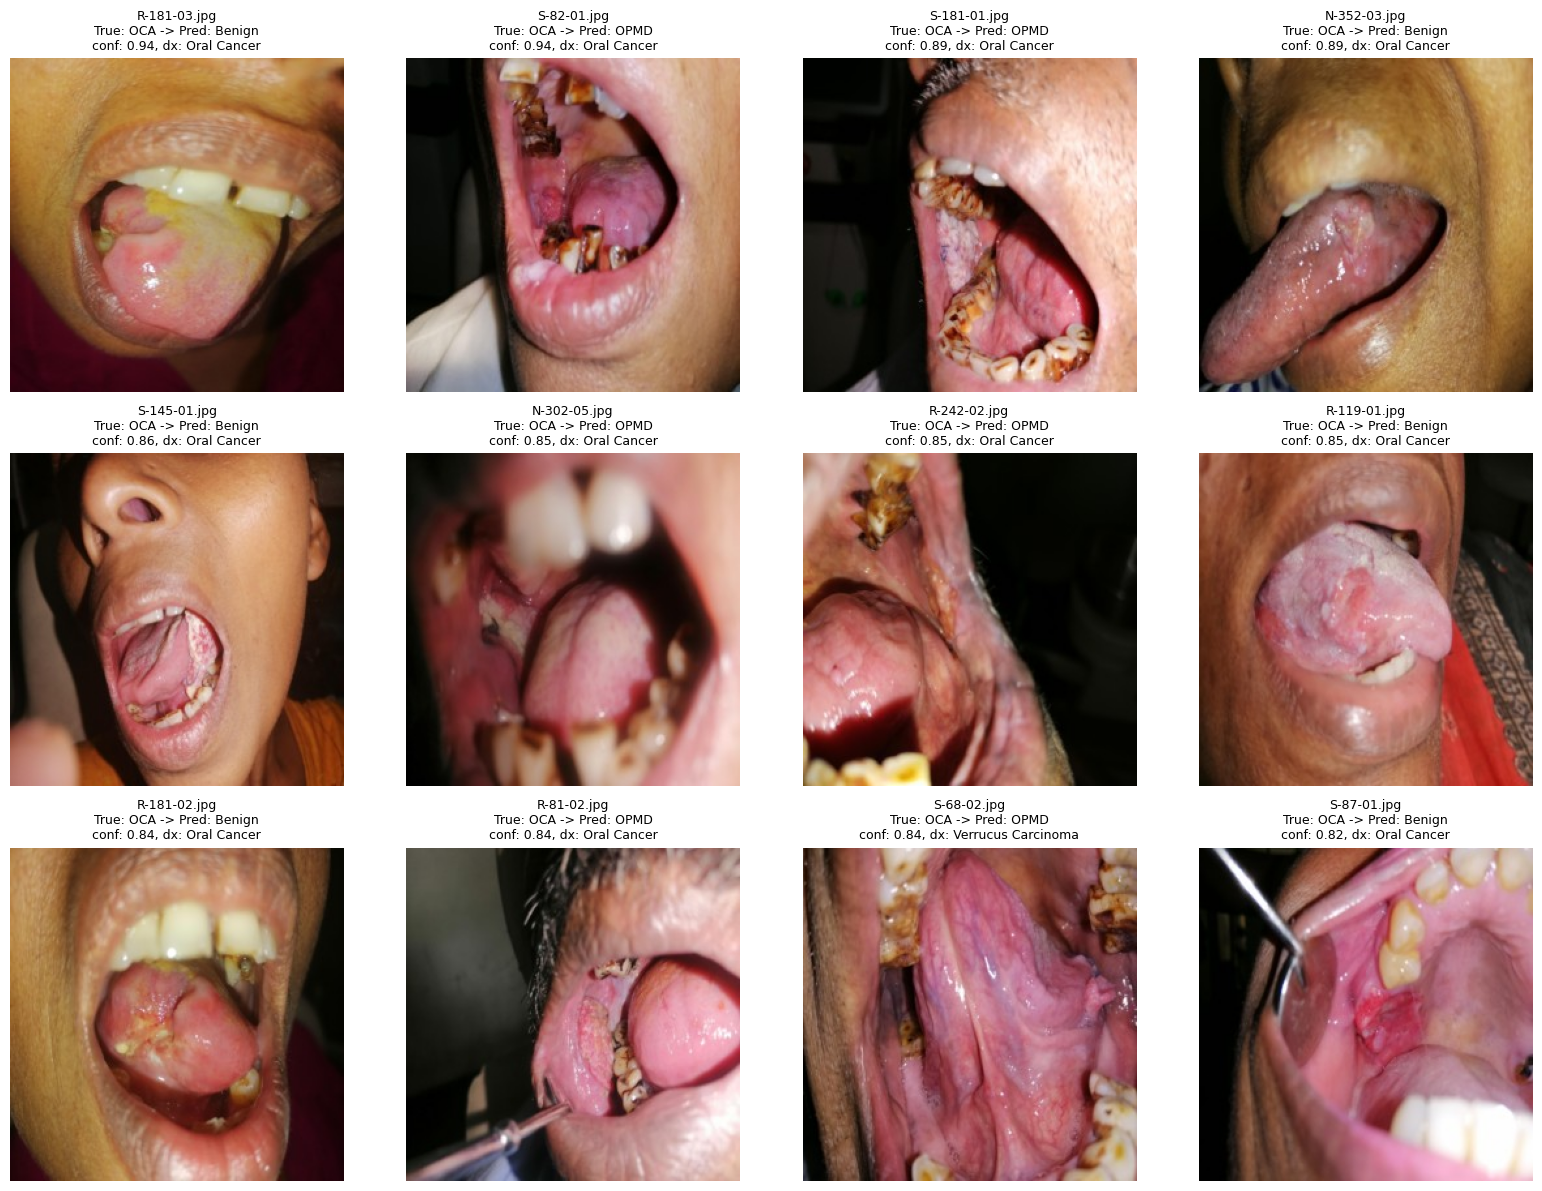

In [12]:
import matplotlib.pyplot as plt

oof_df = pd.read_csv(CONFIG["oof_preds_path"])

oca_true = oof_df[oof_df["label_name"] == "OCA"].copy()
oca_correct = oca_true[oca_true["pred_name"] == "OCA"]
oca_wrong = oca_true[oca_true["pred_name"] != "OCA"]

print(f"OCA images: {len(oca_true)} total, {len(oca_correct)} correct, {len(oca_wrong)} misclassified")
print("\nWhere the misclassified OCA images ended up:")
print(oca_wrong["pred_name"].value_counts())

# Merge back patient_id and clinical diagnosis for context, if available in df
oca_wrong = oca_wrong.merge(
    df[["file_name", "Clinical Diagnosis"]].drop_duplicates("file_name"),
    on="file_name", how="left"
)

# Sort by model confidence in its (wrong) prediction, highest confidence wrong answers are most interesting
oca_wrong["confidence_in_wrong_pred"] = oca_wrong.apply(
    lambda row: row[f"prob_{row['pred_name']}"], axis=1
)
oca_wrong = oca_wrong.sort_values("confidence_in_wrong_pred", ascending=False)

print("\nTop 10 most confidently wrong OCA predictions:")
print(oca_wrong[["file_name", "Clinical Diagnosis", "pred_name", "confidence_in_wrong_pred", "prob_OCA"]].head(10).to_string(index=False))

# Visualize the 12 most confidently wrong ones
n_show = min(12, len(oca_wrong))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, (_, row) in zip(axes.flat, oca_wrong.head(n_show).iterrows()):
    img_path = CACHE_DIR / row["file_name"]
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{row['file_name']}\nTrue: OCA -> Pred: {row['pred_name']}\n"
                 f"conf: {row['confidence_in_wrong_pred']:.2f}, dx: {row['Clinical Diagnosis']}",
                 fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()